In [6]:
import pandas as pd
import numpy as np
import os
import re

# for visualizing
import plotly
import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [38]:
# import data 
data = pd.read_excel('boxplot_dummy_data.xlsx').drop(columns = 'Unnamed: 0')
data

,entities,year,file,number,color
0,Company 1,2023,all files,100000,bisque
1,Company 1,2022,all files,300000,bisque
2,Company 1,2021,all files,800000,bisque
3,Company 1,2020,all files,900000,bisque
4,Company 2,2023,all files,200000,bisque
5,Company 2,2022,all files,400000,bisque
6,Company 2,2021,all files,700000,bisque
7,Company 2,2020,all files,850000,bisque
8,Company 3,2023,all files,150000,bisque
9,Company 3,2022,all files,600000,bisque


### Static - using seaborn

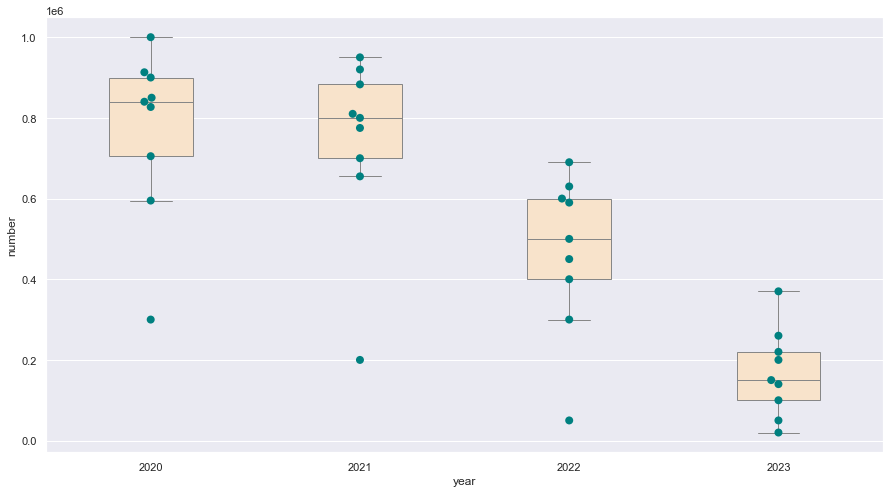

In [39]:
sns.set(style = 'darkgrid')

# plot parameters
plt.figure(figsize = (15, 8))

# creates the boxplots
ax = sns.boxplot(x = 'year', y = 'number', data = data,
                 showfliers = False, color = 'bisque',
                 linewidth = 1, width = 0.4)

# plots the points
ax = sns.swarmplot(x = 'year', y = 'number', data = data, 
                   color = "teal", dodge = True, size = 8)

plt.show()

In [30]:
all_files = data.copy()

### Dynamic

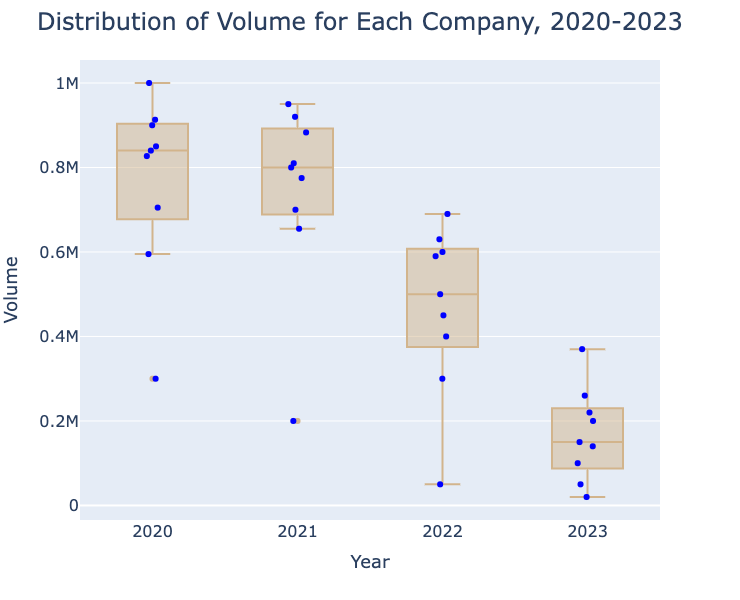

In [43]:

# creates the boxplots
plot = px.box(all_files, x = all_files['year'], y = all_files['number'],
              color_discrete_sequence = ['tan'],
              boxmode = 'overlay', 
              category_orders={'year':('2020', '2021', '2022', '2023')}
              )

# if I want to turn off hover info for the boxplots
plot = plot.update_traces(hovertemplate = None, hoverinfo = 'none')

# plots the points (not in a straight line)
fig = px.strip(all_files, x = all_files['year'], y = all_files['number'],
               stripmode = 'overlay', width = 40, # change width?
               color_discrete_sequence = ['blue'], 
               category_orders={'year':('2020', '2021', '2022', '2023')}, 
              hover_name = 'entities', hover_data = ['year', 'number'])

# overlays the box plot and strip scatterplot together
plot = plot.add_traces(list(fig.select_traces()))

plot.update_layout(autosize = False, 
                  width = 1000, 
                  height = 600, 
                  title = dict(text = "Distribution of Volume for Each Company, 2020-2023",
                               font = dict(size = 24)),
                  xaxis_title = dict(text = 'Year', font_size = 18),
                  yaxis_title = dict(text = 'Volume', font_size = 18),
                  font_size = 16)

'''
##### Option 2 - interactive, but points are not jittered so they are hard to see
plot = go.Figure()
# creates the boxplots for each year
plot = plot.add_trace(go.Box(x = all_files['year'], y = all_files['number'], fillcolor = 'bisque', 
                             line = dict(color = 'lightgray'))) # use "boxpoints = 'all'",
                             pointpos = 0 to plot points -- but can't change color
# plot the points
plot = plot.add_trace(go.Scatter(x = all_files['year'], y = all_files['number'],
                      mode = 'markers', marker_color= 'teal', marker_size = 12,
                      x0= 0, marker_opacity = 0.5, marker_line = dict(color = 'white', width = 2)))
'''

plot.show()

In [44]:
os.getcwd()
plotly.offline.plot(plot, filename = 'boxplot_dynamic.html')

'boxplot_dynamic.html'